# Testing Combined H5 Processing

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx
import matplotlib.cm as cm
import h5py
import logging
import awkward as ak
import uproot

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

from pathlib import Path
import logging

# Reuse postprocessing helpers
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/scripts/postprocessing")
from convert_particles import build_particles_df_with_parents_and_vertex, write_particles_with_selection
from convert_digihits import process_event_for_digihits, write_digihits_with_selection
from utils.path_utils import get_run_paths, make_dir
from utils.track_utils import load_root_file, load_track_summary, create_particle_barcode_map

from convert_all import convert_all


## Single Event Testing

In [3]:
edm_input_file = "/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root"
event = EDM4hepEvent(edm_input_file, event_index=0)

In [4]:
edm_input_file = "/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v7/runs/0/edm4hep.root"
event2 = EDM4hepEvent(edm_input_file, event_index=0)

In [9]:
print(f"""
Number of calo hits: {len(event.get_calo_hits_df())}
Number of particles: {len(event.get_particles_df())}
Number of tracker hits: {len(event.get_tracker_hits_df())}
""")


Number of calo hits: 1243953
Number of particles: 880327
Number of tracker hits: 240622



In [10]:
print(f"""
Number of calo hits: {len(event2.get_calo_hits_df())}
Number of particles: {len(event2.get_particles_df())}
Number of tracker hits: {len(event2.get_tracker_hits_df())}
""")


Number of calo hits: 1120404
Number of particles: 190319
Number of tracker hits: 217781



In [11]:
event2.get_calo_hits_df()

,cellID,energy,x,y,z,contribution_begin,contribution_end,detector,r,R,phi,theta,eta
0,152559394436048912,3.538352e-04,1190.580322,437.952515,2759.100098,0,9,ECalBarrelCollection,1268.575562,3036.760986,0.352486,0.430956,1.519249
1,4503814384687120,5.628845e-05,-274.604279,-1329.300415,81.599998,9,10,ECalBarrelCollection,1357.367676,1359.818237,-1.774509,1.510752,0.060080
2,1970496644814864,2.591849e-05,-333.317444,-1337.777222,35.700001,10,11,ECalBarrelCollection,1378.676270,1379.138428,-1.814982,1.544908,0.025892
3,5348204955310096,3.629815e-04,-325.826416,-1346.346069,96.900002,11,18,ECalBarrelCollection,1385.211426,1388.596558,-1.808239,1.500957,0.069896
4,64176406367602704,8.606262e-05,601.779175,-1106.322876,1162.800049,18,19,ECalBarrelCollection,1259.400024,1714.115601,-1.072613,0.825258,0.826083
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1120399,5629340626780692,2.156135e-09,1199.873169,342.497345,-3698.500000,5346121,5346123,HCalEndcapCollection,1247.798096,3903.319336,0.278050,2.816205,-1.807007
1120400,1407215976088084,5.042664e-04,1112.082520,-98.856026,-3647.500000,5346123,5346129,HCalEndcapCollection,1116.467651,3814.545410,-0.088660,2.844557,-1.899660
1120401,844300382437908,2.557875e-06,864.988586,-110.881462,-3698.500000,5346129,5346132,HCalEndcapCollection,872.066467,3799.921387,-0.127493,2.910033,-2.151582
1120402,5066390673457684,1.597710e-08,1188.167725,283.650238,-3851.500000,5346132,5346133,HCalEndcapCollection,1221.556396,4040.575684,0.234343,2.834465,-1.865733


In [12]:
event2.get_calo_contributions_df()

,PDG,energy,time,step_x,step_y,step_z,particle_id,cellID,x,y,z,detector
0,0,1.297844e-05,2562.023438,0.0,0.0,0.0,75414,0,1190.580322,437.952515,2759.100098,ECalBarrelCollection
1,0,8.172441e-06,2562.023438,0.0,0.0,0.0,75414,0,1190.580322,437.952515,2759.100098,ECalBarrelCollection
2,0,4.534445e-06,2562.023438,0.0,0.0,0.0,75414,0,1190.580322,437.952515,2759.100098,ECalBarrelCollection
3,0,1.256829e-05,2562.023682,0.0,0.0,0.0,75414,0,1190.580322,437.952515,2759.100098,ECalBarrelCollection
4,0,1.282355e-05,2562.023926,0.0,0.0,0.0,75414,0,1190.580322,437.952515,2759.100098,ECalBarrelCollection
...,...,...,...,...,...,...,...,...,...,...,...,...
5346129,0,9.253779e-07,187.780411,0.0,0.0,0.0,1036,201624,864.988586,-110.881462,-3698.500000,HCalEndcapCollection
5346130,0,1.031067e-06,188.810455,0.0,0.0,0.0,1036,201624,864.988586,-110.881462,-3698.500000,HCalEndcapCollection
5346131,0,6.014303e-07,189.794922,0.0,0.0,0.0,1036,201624,864.988586,-110.881462,-3698.500000,HCalEndcapCollection
5346132,0,1.597710e-08,1742.137573,0.0,0.0,0.0,1036,201625,1188.167725,283.650238,-3851.500000,HCalEndcapCollection


## Combined multi-output conversion (single open per run)

This workflow opens each `edm4hep.root` once per run and produces multiple H5 outputs (truth/particles and reco/tracker_hits) in one pass, reusing preloaded DataFrames to avoid repeated IO.


In [3]:
# Configurable column selection for H5 outputs
particles_columns_keep = [
    "particle_id", "pdg_id", "mass", "energy", "charge",
    "vx", "vy", "vz", "time", "px", "py", "pz",
    "num_tracker_hits", "num_calo_hits", "vertex_primary", "parent_id",
]
digihits_columns_keep = [
    "x", "y", "z", "time", "particle_id",
    "cell_id", "detector", "event_id",
]


In [4]:
# Config for this combined test (aligns with your production YAMLs)
campaign = "full_pileup_pilot"
dataset = "ttbar"
version = "v2"

base_root = Path("/pscratch/sd/d/danieltm/ColliderML/simulation")
output_base_dir = Path("./h5_testing/v2")  # unified root like scripts

logging.basicConfig(
    level=logging.DEBUG,  # show DEBUG and above
    format="%(asctime)s - %(levelname)s - %(name)s - %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,  # override prior configs in this kernel
)

config = {
    "chunk_size": 100,
    "run_size": 128,
    "max_chunks": 1,
    "campaign": "full_pileup_pilot",
    "dataset": "ttbar",
    "version": "v2",
    "common": {
        "output_base_dir": base_root,
    },
    "objects": ["particles", "tracker_hits"],
    "particles_columns_keep": particles_columns_keep,
    "digihits_columns_keep": digihits_columns_keep,
    "min_tracker_hits": 1,
    "h5_output_dir": output_base_dir,
}


In [ ]:
convert_all(config)

2025-09-11 04:14:06,677 - DEBUG - convert_all - Starting conversion with config: campaign=full_pileup_pilot, dataset=ttbar, version=v2
2025-09-11 04:14:06,678 - DEBUG - convert_all - Input base directory: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2
2025-09-11 04:14:06,679 - DEBUG - convert_all - Output base directory: h5_testing/v2
2025-09-11 04:14:06,679 - DEBUG - convert_all - Chunk size: 100, Run size: 128
2025-09-11 04:14:06,679 - DEBUG - convert_all - Objects to convert: ['particles', 'tracker_hits']
2025-09-11 04:14:06,679 - DEBUG - convert_all - Dataset base path: full_pileup_pilot/ttbar/v2
2025-09-11 04:14:06,680 - DEBUG - convert_all - Importing required modules completed
2025-09-11 04:14:06,689 - DEBUG - convert_all - Retrieved 109 run directories from /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2
2025-09-11 04:14:06,694 - DEBUG - convert_all - Created output directories: particles=h5_testing/v2/full_pileup_pilot/ttbar/v

2025-09-11 04:14:06,779 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/particles.root
2025-09-11 04:14:06,780 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/particles.root
2025-09-11 04:14:06,790 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/particles.root
2025-09-11 04:14:06,799 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/particles.root
2025-09-11 04:14:06,801 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/particles.root
2025-09-11 04:14:06,808 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/particles.root
2025-09-11 04:14:06,850 - DEBUG - asyncio - Using selector: EpollSelec

## Test

In [58]:
import pandas as pd
import h5py

def load_all_particles(h5_path):
    with h5py.File(h5_path, 'r') as f:
        frames = []
        for ev_name in f['events'].keys():
            ev_id = int(ev_name.split('_')[1])
            arr = f['events'][ev_name]['particles'][:]
            df = pd.DataFrame(arr)
            df['event_id'] = ev_id
            frames.append(df)
        return pd.concat(frames, ignore_index=True)

def load_all_digihits(h5_path):
    with h5py.File(h5_path, 'r') as f:
        frames = []
        for ev_name in f['events'].keys():
            ev_id = int(ev_name.split('_')[1])
            arr = f['events'][ev_name]['measurements'][:]
            df = pd.DataFrame(arr)
            df['event_id'] = ev_id
            frames.append(df)
        return pd.concat(frames, ignore_index=True)

def load_all_tracks(h5_path):
    with h5py.File(h5_path, 'r') as f:
        frames = []
        hit_frames = []
        events = f.get('events')
        if events is None:
            return pd.DataFrame(), None
        for ev_name in events.keys():
            ev = events[ev_name]
            try:
                ev_id = int(ev_name.split('_')[1])
            except Exception:
                continue
            # Tracks table
            if 'tracks' not in ev:
                continue
            arr = ev['tracks'][:]
            df = pd.DataFrame(arr)
            df['event_id'] = ev_id
            frames.append(df)

            # Reconstruct hit_ids from CSR or fall back to legacy vlen
            if 'hit_ids_data' in ev and 'hit_ids_indptr' in ev:
                data = ev['hit_ids_data'][:]
                indptr = ev['hit_ids_indptr'][:]
                if indptr is not None and len(indptr) >= 1:
                    hit_lists = [data[indptr[i]:indptr[i+1]] for i in range(len(indptr) - 1)]
                else:
                    hit_lists = []
                hit_df = pd.DataFrame({
                    'event_id': ev_id,
                    'track_id': df['track_id'].reset_index(drop=True),
                    'hit_ids': hit_lists
                })
                hit_frames.append(hit_df)
            else:
                logger.warning(f"Missing hit_ids for event {ev_name}")
        tracks_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
        if hit_frames:
            hits_df = pd.concat(hit_frames, ignore_index=True)
            return tracks_df, hits_df
        else:
            return tracks_df, None

In [84]:
particles_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup_pilot/ttbar/v2/truth/particles/full_pileup_pilot.ttbar.v2.truth.particles.events0-99.h5"
digihits_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup_pilot/ttbar/v2/reco/tracker_hits/full_pileup_pilot.ttbar.v2.reco.tracker_hits.events0-99.h5"
tracks_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup_pilot/ttbar/v2/reco/tracks/full_pileup_pilot.ttbar.v2.reco.tracks.events0-99.h5"

In [85]:
particles_df = load_all_particles(particles_file)
digihits_df = load_all_digihits(digihits_file)
tracks_df, track_hits_df = load_all_tracks(tracks_file)

In [86]:
digihits_df = digihits_df[digihits_df.event_id == 0]

In [87]:
particles_df = particles_df[particles_df.event_id == 0]

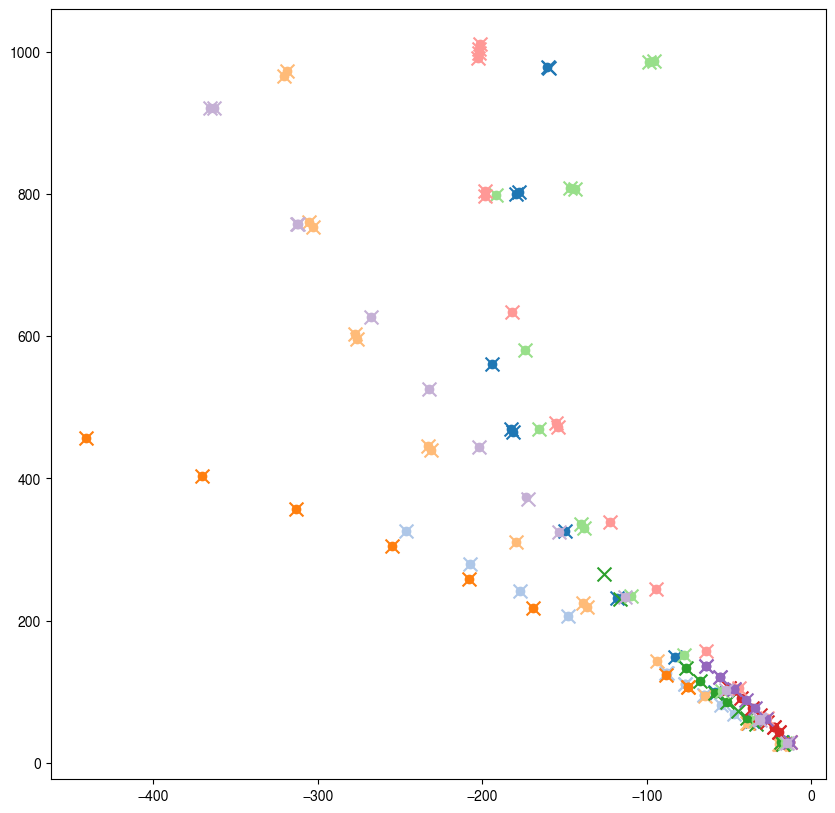

In [115]:
plt.figure(figsize=(10, 10))

num_tracks_to_sample = 10

# Define a list of colors to use for each track/particle pair
# Use tab20 colormap and cycle through it for more colors
cmap = plt.cm.tab20
colors = [cmap(i % 20) for i in range(num_tracks_to_sample)]

for i in range(num_tracks_to_sample):
    track_hit_ids = track_hits_df.iloc[i].hit_ids

    # Use the same color for both track hits and particle hits
    color = colors[i]
    
    plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], marker='o', color=color)

    # Get the majority particle id for the track
    track_majority_particle_id = tracks.iloc[i]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == track_majority_particle_id].index.tolist()
    plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], marker='x', color=color, s=100)

In [116]:
particles_df

,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,vertex_primary,parent_id,event_id
0,81,2212,0.938270,2.088655,1.0,0.009780,-0.003074,-89.848335,-0.765510,-0.153240,0.357442,1.825070,1,10.0,0
1,83,-211,0.139570,0.411130,-1.0,0.009780,-0.003074,-89.848335,-0.765510,-0.349941,-0.123546,-0.108746,1,10.0,0
2,85,-211,0.139570,1.303886,-1.0,0.009780,-0.003074,-89.848335,-0.765510,-0.515224,1.013931,-0.622196,1,10.0,0
3,88,-211,0.139570,0.367787,-1.0,0.009780,-0.003074,-89.848335,-0.765510,0.120762,0.196509,-0.250176,1,10.0,0
4,89,211,0.139570,1.670073,1.0,0.009780,-0.003074,-89.848335,-0.765510,-1.257038,0.601183,-0.909999,1,10.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52097,879525,11,0.000511,0.001878,-1.0,-587.023193,36.333473,2192.566162,14.332582,-0.000897,-0.001288,-0.000895,1,349.0,0
52098,879526,11,0.000511,0.000773,-1.0,242.825897,957.259094,2270.417969,10.273644,-0.000568,-0.000115,-0.000024,1,349.0,0
52099,880214,2112,0.939565,0.939693,0.0,599.215210,1192.483765,2467.749512,12.798975,-0.002671,0.014943,-0.003215,1,880193.0,0
52100,880270,11,0.000511,0.001495,-1.0,44.648663,164.044464,238.886871,0.470167,0.001061,0.000171,0.000904,1,350.0,0


In [117]:
tracks_df

,track_id,num_hits,num_outliers,num_holes,num_shared_hits,chi2,majority_particle_id,d0,z0,phi,...,time,d0_truth,z0_truth,phi_truth,theta_truth,charge_truth,p_truth,pT_truth,time_truth,event_id
0,1344,14,0,0,0,25.0310,37316,0.330416,50.031403,3.122019,...,782.701599,NaN,NaN,NaN,NaN,2147483647,NaN,NaN,NaN,0
1,1337,15,0,0,0,40.3224,37312,-0.023452,1.814370,3.054096,...,1028.467529,0.001409,1.832299,3.052949,0.367983,-1,3.133558,1.127249,1049.892700,0
2,1336,12,0,0,0,17.6963,12750,0.017396,40.272858,3.122701,...,-752.464355,NaN,NaN,NaN,NaN,2147483647,NaN,NaN,NaN,0
3,1332,16,0,0,0,30.8536,4914,-0.112086,22.832439,3.082001,...,-2602.563721,NaN,NaN,NaN,NaN,2147483647,NaN,NaN,NaN,0
4,1328,7,0,2,0,33.5590,65447,-0.021312,7.029703,-3.120268,...,-650.453247,-0.023321,7.075048,-3.120212,1.890899,1,1.313916,1.247174,-641.616028,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81432,1165,12,0,0,0,39.7055,9436,-0.188421,-37.290146,1.119420,...,-2290.905518,NaN,NaN,NaN,NaN,2147483647,NaN,NaN,NaN,99
81433,1166,13,0,0,0,22.7432,52875,-0.255613,34.895561,1.170692,...,1480.306152,-0.003760,35.093563,1.163173,2.241339,1,1.615394,1.265636,1476.166992,99
81434,58,14,0,0,0,40.7166,78338,-0.014685,113.341652,-2.827568,...,-1410.590576,0.011585,113.648216,-2.828277,2.956237,1,9.248423,1.704450,-1418.774536,99
81435,1167,12,1,0,0,32.4154,56874,-0.824323,10.476507,1.154377,...,1354.627930,-0.803388,10.523274,1.152179,2.841318,1,19.622824,5.804096,1413.300049,99


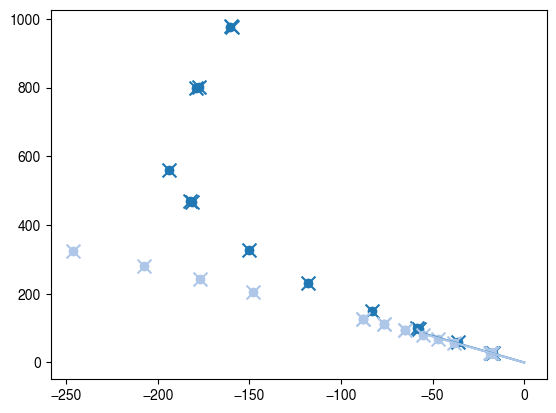

In [144]:
num_tracks_to_sample = 2

colors = [cmap(i % 20) for i in range(num_tracks_to_sample)]

for i in range(num_tracks_to_sample):
    # Plot the track hits
    track_hit_ids = track_hits_df.iloc[i].hit_ids
    plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], marker='o', color=colors[i])

    # Get the majority particle id for the track
    majority_particle_id = tracks.iloc[i]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == majority_particle_id].index.tolist()
    plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], marker='x', color=colors[i], s=100)

    # Plot the phi vector of the particle
    particle_entry = particles_df[particles_df['particle_id'] == majority_particle_id].iloc[0]
    normalised_momentum_vector = particle_entry[['px', 'py']].values / np.linalg.norm(particle_entry[['px', 'py']].values)*100
    plt.plot([particle_entry['vx'], particle_entry['vx'] + normalised_momentum_vector[0]], [particle_entry['vy'], particle_entry['vy'] + normalised_momentum_vector[1]], color=colors[i])


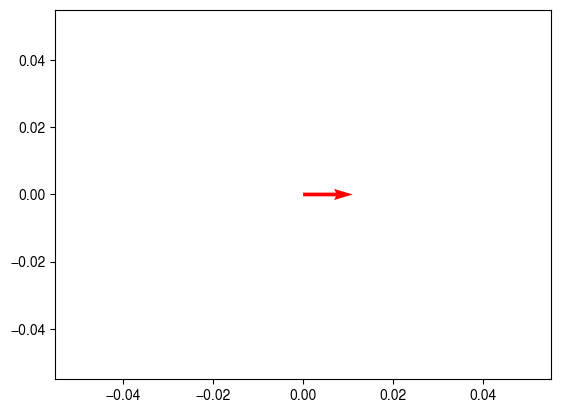

In [140]:
plt.quiver(0, 0, 1, 0, color='red', scale=10)

In [92]:
print("Memory usage:")
print(f"Tracks DataFrame: {tracks_df.memory_usage().sum() / 1024**2:.2f} MB")
print(f"Track Hits DataFrame: {track_hits_df.memory_usage().sum() / 1024**2:.2f} MB")

Memory usage:
Tracks DataFrame: 9.01 MB
Track Hits DataFrame: 1.86 MB


In [97]:
tracks_df.iloc[0]

track_id                1.344000e+03
num_hits                1.400000e+01
num_outliers            0.000000e+00
num_holes               0.000000e+00
num_shared_hits         0.000000e+00
chi2                    2.503100e+01
majority_particle_id    3.731600e+04
d0                      3.304158e-01
z0                      5.003140e+01
phi                     3.122019e+00
theta                   9.326996e-02
qop                     1.094566e-01
time                    7.827016e+02
d0_truth                         NaN
z0_truth                         NaN
phi_truth                        NaN
theta_truth                      NaN
charge_truth            2.147484e+09
p_truth                          NaN
pT_truth                         NaN
time_truth                       NaN
event_id                0.000000e+00
Name: 0, dtype: float64

In [ ]:
particles_df[particles_df['particle_id'] == 37316].iloc[0]

,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,vertex_primary,parent_id,event_id
4022,37316,321,0.49368,3.075686,1.0,-0.014769,-0.007004,13.143684,-13.157919,-0.606526,0.931841,2.824876,109,37301.0,0


## Track Conversion

In [117]:
tracks_df.columns

Index(['track_id', 'num_hits', 'num_outliers', 'num_holes', 'num_shared_hits',
       'chi2', 'majority_particle_id', 'd0', 'z0', 'phi', 'theta', 'qop',
       'time', 'd0_truth', 'z0_truth', 'phi_truth', 'theta_truth',
       'charge_truth', 'p_truth', 'pT_truth', 'time_truth', 'event_id'],
      dtype='object')

In [98]:
# Config for this combined test (aligns with your production YAMLs)
campaign = "full_pileup_pilot"
dataset = "ttbar"
version = "v2"

base_root = Path("/pscratch/sd/d/danieltm/ColliderML/simulation")
output_base_dir = Path("./h5_testing/v2")  # unified root like scripts

logging.basicConfig(
    level=logging.DEBUG,  # show DEBUG and above
    format="%(asctime)s - %(levelname)s - %(name)s - %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,  # override prior configs in this kernel
)

tracks_columns_keep = [
    "event_id", "majority_particle_id", "d0", "z0", "phi", "theta", "qop"
]

run_dir = Path("/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0")

config = {
    "chunk_size": 128,
    "run_size": 128,
    "max_chunks": 1,
    "campaign": "full_pileup_pilot",
    "dataset": "ttbar",
    "version": "v2",
    "common": {
        "output_base_dir": base_root,
    },
    "objects": ["tracks", "tracker_hits"],
    "min_tracker_hits": 1,
    "h5_output_dir": output_base_dir,
}

In [104]:
convert_all(config)

2025-09-12 05:36:27,879 - DEBUG - convert_all - Starting conversion with config: campaign=full_pileup_pilot, dataset=ttbar, version=v2
2025-09-12 05:36:27,881 - DEBUG - convert_all - Input base directory: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2
2025-09-12 05:36:27,881 - DEBUG - convert_all - Output base directory: h5_testing/v2
2025-09-12 05:36:27,882 - DEBUG - convert_all - Objects to convert: ['tracks', 'tracker_hits']
2025-09-12 05:36:27,902 - INFO - convert_all - Found 109 runs. chunk_size=128, run_size=128, chunk_index=None


2025-09-12 05:36:27,971 - INFO - root - Processing 109 runs (13952 events), chunk_size=128 events, 109 chunks
2025-09-12 05:36:27,972 - INFO - root - Capping chunks to 1 (interactive/testing)


Processing chunks:   0%|          | 0/1 [00:00<?, ?it/s]

2025-09-12 05:36:28,143 - DEBUG - pyedm4hep.event_batch - EDM4hepEventBatch init: file=/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root, events=range(0, 128), full_load=False
2025-09-12 05:36:28,145 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/tracksummary_ambi.root
2025-09-12 05:36:28,146 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/tracksummary_ambi.root
2025-09-12 05:36:28,184 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/tracksummary_ambi.root
2025-09-12 05:36:28,192 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/tracksummary_ambi.root
2025-09-12 05:36:28,346 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar

2025-09-12 05:39:02,457 - INFO - convert_all - Writing tracker hits to: h5_testing/v2/full_pileup_pilot/ttbar/v2/reco/tracker_hits/full_pileup_pilot.ttbar.v2.reco.tracker_hits.events0-127.h5 (rows=31623404)
2025-09-12 05:40:02,923 - INFO - convert_all - Wrote tracker hits file: h5_testing/v2/full_pileup_pilot/ttbar/v2/reco/tracker_hits/full_pileup_pilot.ttbar.v2.reco.tracker_hits.events0-127.h5
2025-09-12 05:40:02,958 - INFO - convert_all - Writing tracks to: h5_testing/v2/full_pileup_pilot/ttbar/v2/reco/tracks/full_pileup_pilot.ttbar.v2.reco.tracks.events0-127.h5 (rows=103649)
2025-09-12 05:40:02,981 - DEBUG - h5py._conv - Creating converter from 5 to 9
2025-09-12 05:40:03,550 - INFO - convert_all - Wrote tracks file: h5_testing/v2/full_pileup_pilot/ttbar/v2/reco/tracks/full_pileup_pilot.ttbar.v2.reco.tracks.events0-127.h5


Processing chunks: 100%|██████████| 1/1 [03:36<00:00, 216.78s/it]

2025-09-12 05:40:04,921 - INFO - convert_all - 
Total conversion time: 217.04 seconds
2025-09-12 05:40:04,922 - DEBUG - convert_all - Conversion process completed successfully


In [ ]:
edm4hep_path = run_dir / "edm4hep.root"
run_size = 128
batch = EDM4hepEvent(str(edm4hep_path), event_index=0)

2025-09-12 03:13:03,950 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root
2025-09-12 03:13:03,952 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root
2025-09-12 03:13:03,962 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root
2025-09-12 03:13:03,968 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root
2025-09-12 03:13:03,973 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root
2025-09-12 03:13:03,975 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root
2025-09-12 03:13:04,095 - DEBUG - pyedm4hep.utils - Loading event 0 from /pscratch

In [ ]:
edm_hits_all = batch.get_tracker_hits_df()

2025-09-11 13:48:10,743 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root
2025-09-11 13:48:10,745 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root


2025-09-11 13:48:10,755 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root
2025-09-11 13:48:10,762 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root
2025-09-11 13:48:10,767 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root
2025-09-11 13:48:10,769 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root
2025-09-11 13:48:10,897 - DEBUG - pyedm4hep.event_batch - _load_tracker_hits: start=0, stop=128, list=None
2025-09-11 13:48:10,901 - DEBUG - asyncio - Using selector: EpollSelector
2025-09-11 13:48:10,906 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root
2025-09-11 13:48:10,907 - DEBUG - fsspec.local - open 

In [99]:
ts_path = run_dir / "tracksummary_ckf.root"
tracksummary_arrays = load_track_summary(str(ts_path))

2025-09-15 06:43:02,684 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/tracksummary_ckf.root
2025-09-15 06:43:02,689 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/tracksummary_ckf.root
2025-09-15 06:43:02,702 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/tracksummary_ckf.root
2025-09-15 06:43:02,710 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/tracksummary_ckf.root
2025-09-15 06:43:02,712 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/tracksummary_ckf.root
2025-09-15 06:43:02,720 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/tracksummary_ckf.root
2025-09-15 06:43:02,919 - DE

In [104]:
ak.to_dataframe(tracksummary_arrays)

KeyboardInterrupt: 

In [ ]:
simhits_path = run_dir / "simhits.root"
included_columns = [
    "event_id",
    "tx", "ty", "tz",
    "particle_id"
simhits_df_all = load_root_file(str(simhits_path), included_columns=included_columns)

2025-09-11 13:07:00,024 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/simhits.root
2025-09-11 13:07:00,027 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/simhits.root
2025-09-11 13:07:00,034 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/simhits.root
2025-09-11 13:07:00,041 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/simhits.root
2025-09-11 13:07:00,077 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/simhits.root


In [ ]:
measurements_path = run_dir / "measurements.root"
included_columns = [
    "event_nr",
    "true_x",
    "true_y",
    "true_z",
]

measurements_df_all = load_root_file(str(measurements_path), included_columns=included_columns)

2025-09-11 13:45:58,831 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/measurements.root
2025-09-11 13:45:58,834 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/measurements.root
2025-09-11 13:45:58,880 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/measurements.root
2025-09-11 13:45:58,890 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/measurements.root
2025-09-11 13:45:58,941 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/measurements.root
2025-09-11 13:45:58,941 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/measurements.root
2025-09-11 13:45:58,942 - DEBUG - fsspec.local - ope

In [ ]:
measurements_df_all

In [ ]:
simhits_df_all

,event_id,geometry_id,particle_id,tx,ty,tz,tt,tpx,tpy,tpz,...,deltapx,deltapy,deltapz,deltae,index,volume_id,boundary_id,layer_id,approach_id,sensitive_id
entry,,,,,,,,,,,,,,,,,,,,,
0,35,1152921779484754177,212645548812143836,63.643333,-8.139078,-1515.599976,927.368225,-0.006183,0.015006,-0.097171,...,0.0,0.0,0.0,-0.000042,-1,16,0,4,0,1
1,35,1152921779484754177,739165383470154328,87.585510,-3.821328,-1515.599976,2322.165283,0.341385,-0.072622,-3.435519,...,0.0,0.0,0.0,-0.000045,-1,16,0,4,0,1
2,35,1152921779484754177,365626099142691262,80.713394,1.892023,-1515.599976,935.678589,-0.014898,0.024516,-0.123208,...,0.0,0.0,0.0,-0.000037,-1,16,0,4,0,1
3,35,1152921779484754177,58546795155816477,80.424278,6.472737,-1515.599976,2500.890137,0.861348,0.090819,-16.802523,...,0.0,0.0,0.0,-0.000034,-1,16,0,4,0,1
4,35,1152921779484754177,58546795155882132,80.445496,6.482724,-1515.637817,2500.949951,0.001047,0.000554,-0.001443,...,0.0,0.0,0.0,-0.000056,-1,16,0,4,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31624195,125,2161728645771608066,189304016465953120,362.569031,887.819702,3009.500000,2842.476318,0.682261,0.638534,2.932003,...,0.0,0.0,0.0,-0.000075,-1,30,0,12,0,192
31624196,125,2161728645771608066,460274259084838661,324.550476,904.804993,3009.500000,348.326569,0.153333,0.012081,0.448401,...,0.0,0.0,0.0,-0.000079,-1,30,0,12,0,192
31624197,125,2161728645771608066,869332167036305661,332.605164,922.943604,3009.589600,3652.262695,0.000065,0.000012,0.000023,...,0.0,0.0,0.0,-0.000019,-1,30,0,12,0,192


In [ ]:
tracks_csv_pattern = "event{:09d}-tracks_ckf.csv"

In [105]:
local_event_num = 0
global_event_num = 0

In [ ]:
tracks_csv = pd.read_csv(run_dir / tracks_csv_pattern.format(local_event_num))

In [ ]:
tracks_csv

NameError: name 'tracks_csv' is not defined

In [ ]:
tracks_csv.Hit_ID

In [118]:
tracksummary_arrays

<Array [{event_nr: 35, ...}, {...}, ..., {...}] type='128 * {event_nr: uint...'>

In [125]:
run_size = 128
per_event_frames: list[pd.DataFrame] = []
for idx in range(run_size):
    if idx >= len(tracksummary_arrays):
        break
    entry = tracksummary_arrays[idx]
    if not hasattr(entry, 'fields'):
        continue
    row_dict = {}
    for field in entry.fields:
        if field == 'event_nr':
            continue
        try:
            row_dict[field] = ak.to_numpy(entry[field])
        except Exception:
            continue
    if not row_dict:
        continue
    df_entry = pd.DataFrame(row_dict)
    df_entry['event_nr'] = entry.event_nr
    df_entry = df_entry.rename(columns={'track_nr': 'track_id'})
    per_event_frames.append(df_entry)
track_fitting_df_run = pd.concat(per_event_frames, ignore_index=True) if per_event_frames else pd.DataFrame()

In [126]:
track_fitting_df_run

,track_id,nStates,nMeasurements,nOutliers,nHoles,nSharedHits,chi2Sum,NDF,nMajorityHits,majorityParticleId,...,cov_eQOP_eTHETA,cov_eQOP_eQOP,cov_eQOP_eT,cov_eT_eLOC0,cov_eT_eLOC1,cov_eT_ePHI,cov_eT_eTHETA,cov_eT_eQOP,cov_eT_eT,event_nr
0,0,27,15,0,0,0,34.886196,29,15,247697979505443102,...,1.139264e-10,0.000007,0.000007,0.000003,-0.000697,2.192706e-07,-0.000014,0.000007,124.826729,35
1,1,25,10,0,3,0,27.568527,27,4294967295,18446744073709551615,...,-1.375856e-09,0.000017,0.000009,-0.000714,-0.567578,-1.099664e-05,-0.000296,0.000009,89.760185,35
2,2,25,10,0,3,0,25.080715,27,4294967295,18446744073709551615,...,-7.003329e-11,0.000017,-0.000007,-0.001230,-1.605775,-6.021466e-05,-0.000806,-0.000007,90.790405,35
3,3,25,13,0,0,0,13.450335,27,13,774619135907790861,...,3.109341e-09,0.000025,-0.000036,0.000006,-0.000831,-8.879089e-07,-0.000020,-0.000036,124.826721,35
4,4,14,6,1,0,0,23.002394,17,4294967295,18446744073709551615,...,-7.227623e-10,0.000278,0.000623,-0.000461,-0.000427,2.233545e-05,-0.000012,0.000623,124.827835,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
866650,7690,27,12,1,2,0,18.273628,19,4294967295,18446744073709551615,...,6.555243e-07,0.000037,-0.000045,0.000179,-0.013724,-9.334683e-06,-0.000280,-0.000045,620.691956,125
866651,7691,27,12,0,3,0,21.326105,19,4294967295,18446744073709551615,...,6.668072e-07,0.000037,-0.000045,0.000155,-0.013992,-8.669982e-06,-0.000284,-0.000045,620.692139,125
866652,7692,30,15,0,2,0,36.646267,28,14,653021945968722169,...,-2.214735e-09,0.000003,0.000003,0.000173,0.003217,-2.405833e-06,0.000030,0.000003,155.981445,125
866653,7693,25,10,2,1,0,50.606293,18,4294967295,18446744073709551615,...,3.516326e-08,0.000041,-0.000047,0.000041,-0.001131,-1.527174e-06,-0.000027,-0.000047,311.417755,125


In [ ]:
track_fitting_df_run

,track_id,nStates,nMeasurements,nOutliers,nHoles,nSharedHits,chi2Sum,NDF,nMajorityHits,majorityParticleId,...,cov_eQOP_eTHETA,cov_eQOP_eQOP,cov_eQOP_eT,cov_eT_eLOC0,cov_eT_eLOC1,cov_eT_ePHI,cov_eT_eTHETA,cov_eT_eQOP,cov_eT_eT,event_nr
0,0,27,15,0,0,0,34.886196,29,15,247697979505443102,...,1.139264e-10,0.000007,0.000007,0.000003,-0.000697,2.192706e-07,-0.000014,0.000007,124.826729,0
1,1,25,10,0,3,0,27.568527,27,4294967295,18446744073709551615,...,-1.375856e-09,0.000017,0.000009,-0.000714,-0.567578,-1.099664e-05,-0.000296,0.000009,89.760185,0
2,2,25,10,0,3,0,25.080715,27,4294967295,18446744073709551615,...,-7.003329e-11,0.000017,-0.000007,-0.001230,-1.605775,-6.021466e-05,-0.000806,-0.000007,90.790405,0
3,3,25,13,0,0,0,13.450335,27,13,774619135907790861,...,3.109341e-09,0.000025,-0.000036,0.000006,-0.000831,-8.879089e-07,-0.000020,-0.000036,124.826721,0
4,4,14,6,1,0,0,23.002394,17,4294967295,18446744073709551615,...,-7.227623e-10,0.000278,0.000623,-0.000461,-0.000427,2.233545e-05,-0.000012,0.000623,124.827835,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
866650,7690,27,12,1,2,0,18.273628,19,4294967295,18446744073709551615,...,6.555243e-07,0.000037,-0.000045,0.000179,-0.013724,-9.334683e-06,-0.000280,-0.000045,620.691956,127
866651,7691,27,12,0,3,0,21.326105,19,4294967295,18446744073709551615,...,6.668072e-07,0.000037,-0.000045,0.000155,-0.013992,-8.669982e-06,-0.000284,-0.000045,620.692139,127
866652,7692,30,15,0,2,0,36.646267,28,14,653021945968722169,...,-2.214735e-09,0.000003,0.000003,0.000173,0.003217,-2.405833e-06,0.000030,0.000003,155.981445,127
866653,7693,25,10,2,1,0,50.606293,18,4294967295,18446744073709551615,...,3.516326e-08,0.000041,-0.000047,0.000041,-0.001131,-1.527174e-06,-0.000027,-0.000047,311.417755,127


In [106]:
arrays = tracksummary_arrays[local_event_num]
track_data = {}
for field in getattr(arrays, 'fields', []):
    if field == 'event_nr':
        continue
    try:
        array = ak.to_numpy(arrays[field])
        assert len(array.shape) == 1
        track_data[field] = array
    except Exception as e:
        continue


track_fitting_df = pd.DataFrame(track_data).rename(columns={"track_nr": "track_id"})

In [108]:
track_fitting_df.columns

Index(['track_id', 'nStates', 'nMeasurements', 'nOutliers', 'nHoles',
       'nSharedHits', 'chi2Sum', 'NDF', 'nMajorityHits', 'majorityParticleId',
       'trackClassification', 't_charge', 't_time', 't_vx', 't_vy', 't_vz',
       't_px', 't_py', 't_pz', 't_theta', 't_phi', 't_eta', 't_p', 't_pT',
       't_d0', 't_z0', 't_prodR', 'hasFittedParams', 'eLOC0_fit', 'eLOC1_fit',
       'ePHI_fit', 'eTHETA_fit', 'eQOP_fit', 'eT_fit', 'err_eLOC0_fit',
       'err_eLOC1_fit', 'err_ePHI_fit', 'err_eTHETA_fit', 'err_eQOP_fit',
       'err_eT_fit', 'res_eLOC0_fit', 'res_eLOC1_fit', 'res_ePHI_fit',
       'res_eTHETA_fit', 'res_eQOP_fit', 'res_eT_fit', 'pull_eLOC0_fit',
       'pull_eLOC1_fit', 'pull_ePHI_fit', 'pull_eTHETA_fit', 'pull_eQOP_fit',
       'pull_eT_fit', 'cov_eLOC0_eLOC0', 'cov_eLOC0_eLOC1', 'cov_eLOC0_ePHI',
       'cov_eLOC0_eTHETA', 'cov_eLOC0_eQOP', 'cov_eLOC0_eT', 'cov_eLOC1_eLOC0',
       'cov_eLOC1_eLOC1', 'cov_eLOC1_ePHI', 'cov_eLOC1_eTHETA',
       'cov_eLOC1_eQOP', 'cov_e

In [113]:
track_fitting_df[["track_id", "t_d0", "t_z0", "t_pT", "eLOC0_fit", "err_eLOC0_fit"]]

,track_id,t_d0,t_z0,t_pT,eLOC0_fit,err_eLOC0_fit
0,0,-0.000411,55.380894,1.804305,0.039595,0.036361
1,1,NaN,NaN,NaN,-0.478556,0.090417
2,2,NaN,NaN,NaN,-0.496494,0.134990
3,3,-0.014354,-38.338657,1.184893,-0.011487,0.048994
4,4,NaN,NaN,NaN,-0.015330,0.065089
...,...,...,...,...,...,...
5357,5357,0.031989,-1.811516,1.443408,-0.272601,0.096751
5358,5358,0.031989,-1.811516,1.443408,-0.508847,0.084795
5359,5359,-0.002393,55.441132,2.069673,-0.089647,0.100188
5360,5360,-0.002393,55.441132,2.069673,-0.090183,0.101425


In [21]:
arrays

<Record {event_nr: 35, track_nr: [...], ...} type='{event_nr: uint32, track...'>

In [29]:
local_event_edm4hep_hits = edm_hits_all[edm_hits_all.event_id == local_event_num]
local_event_simhits = simhits_df_all[simhits_df_all.event_id == local_event_num]

In [32]:
particle_barcode_map = create_particle_barcode_map(local_event_edm4hep_hits, local_event_simhits)

In [ ]:
particle_barcode_map

particle_id
887747887289730063     95877
306626305196295411    642692
306244774661391531    640856
126100789566439591     10024
198158383604301835     18449
                       ...  
653021945968854996    342993
58594074156007571     840456
639526540249596046    376977
612489549322584623    433617
288571224756520102    658388
Name: particle_barcode, Length: 52102, dtype: int32

: 

## Check track hits truth

In [81]:
base_path = Path("/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0")
edm4hep_path = base_path / "edm4hep.root"
simhits_path = base_path / "simhits.root"
measurements_path = base_path / "measurements.root"
particles_path = base_path / "particles.root"

# Load edm4hep event
event = EDM4hepEvent(str(edm4hep_path), event_index=0)
# Get tracker hits
tracker_hits = event.get_tracker_hits_df()
# Get particles
particles_df = event.get_particles_df()

2025-09-12 04:34:27,260 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root
2025-09-12 04:34:27,263 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root
2025-09-12 04:34:27,272 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root
2025-09-12 04:34:27,279 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root
2025-09-12 04:34:27,387 - DEBUG - pyedm4hep.utils - Loading event 0 from /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root...
2025-09-12 04:34:27,399 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root
2025-09-12 04:34:27,399 - DEBUG - fsspec.local - open file: /pscra

In [7]:
# Load simhits
simhits = load_root_file(str(simhits_path), event_id=0, included_columns=["event_id", "particle_id", "tx", "ty", "tz"])

2025-09-12 03:27:45,398 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/simhits.root
2025-09-12 03:27:45,400 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/simhits.root
2025-09-12 03:27:45,409 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/simhits.root
2025-09-12 03:27:45,415 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/simhits.root
2025-09-12 03:27:45,434 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/simhits.root
2025-09-12 03:27:45,434 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/simhits.root
2025-09-12 03:27:45,435 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danielt

In [30]:
# Load measurements
measurements = load_root_file(str(measurements_path), event_id=0, included_columns=["event_id", "particle_id", "true_x", "true_y", "true_z"])

2025-09-12 03:43:23,392 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/measurements.root
2025-09-12 03:43:23,395 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/measurements.root
2025-09-12 03:43:23,401 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/measurements.root
2025-09-12 03:43:23,409 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/measurements.root


2025-09-12 03:43:23,434 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/measurements.root
2025-09-12 03:43:23,435 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/measurements.root
2025-09-12 03:43:23,435 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/measurements.root
2025-09-12 03:43:23,436 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/measurements.root
2025-09-12 03:43:23,436 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/measurements.root
2025-09-12 03:43:23,436 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/measurements.root
2025-09-12 03:43:23,437 - DEBUG - fsspec.local - ope

In [42]:
# Load particles
particles = load_root_file(str(particles_path), event_id=0, included_columns=["event_id", "particle_id", "px", "py", "pz", "vx", "vy", "vz"])

2025-09-12 03:54:59,047 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/particles.root
2025-09-12 03:54:59,052 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/particles.root
2025-09-12 03:54:59,062 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/particles.root
2025-09-12 03:54:59,073 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/particles.root
2025-09-12 03:54:59,358 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/particles.root
2025-09-12 03:54:59,358 - DEBUG - fsspec.local - open file: /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/particles.root
2025-09-12 03:54:59,363 - DEBUG - fsspec.local - open file: /pscratch/

In [10]:
tracks_csv = pd.read_csv(base_path / "event000000000-tracks_ckf.csv")

In [12]:
simhits.columns

Index(['event_id', 'particle_id', 'tx', 'ty', 'tz'], dtype='object')

In [14]:
measurements.columns

Index(['true_x', 'true_y', 'true_z'], dtype='object')

In [20]:
simhits

,event_id,particle_id,tx,ty,tz
entry,,,,,
0,0,193663580070084651,85.631775,3.625161,-1515.599976
1,0,761108337025679422,92.851669,-3.027657,-1515.599976
2,0,834744829761229871,66.317802,-7.857886,-1515.599976
3,0,261320928573718739,65.890350,-3.451361,-1515.599976
4,0,639627695319286115,92.188545,-4.542456,-1515.599976
...,...,...,...,...,...
240617,0,869194728082571378,421.881561,942.290344,3009.500000
240618,0,653021945968854818,306.645935,886.782227,3009.500000
240619,0,428042075716911252,331.738159,868.459473,3009.500000


In [21]:
measurements

,true_x,true_y,true_z
entry,,,
0,85.631775,3.625161,-1515.599976
1,92.851669,-3.027657,-1515.599976
2,66.317802,-7.857886,-1515.599976
3,65.890350,-3.451361,-1515.599976
4,92.188545,-4.542456,-1515.599976
...,...,...,...
240609,421.881561,942.290344,3009.500000
240610,306.645935,886.782227,3009.500000
240611,331.738159,868.459473,3009.500000


In [26]:
def convert_hit_ids(hit_ids_str: str) -> np.ndarray:
    hit_ids_str = hit_ids_str.strip('[]').split(',')
    result = np.array([int(x) for x in hit_ids_str if x.strip()], dtype=np.int32)
    return result

def get_majority_barcode(hit_ids, simhits_root_df):
    track_hits = simhits_root_df.iloc[convert_hit_ids(hit_ids)]
    # Get the majority barcode
    majority_barcode = track_hits.particle_id.mode()[0]
    return majority_barcode

def get_majority_count(hit_ids, simhits_root_df):
    track_hits = simhits_root_df.iloc[convert_hit_ids(hit_ids)]
    majority_count = track_hits.particle_id.value_counts().max()
    return majority_count

tracks_csv["majority_barcode"] = tracks_csv.Measurements_ID.apply(get_majority_barcode, simhits_root_df=simhits)
tracks_csv["majority_count"] = tracks_csv.Measurements_ID.apply(get_majority_count, simhits_root_df=simhits)
tracks_csv

,track_id,seed_id,particleId,nStates,nMajorityHits,nMeasurements,nOutliers,nHoles,nSharedHits,chi2,ndf,chi2/ndf,pT,eta,phi,truthMatchProbability,good/duplicate/fake,Measurements_ID,majority_barcode,majority_count
0,6527,554834,vp=138|vs=0|p=0|g=1|sp=389,26,10,10,0,2,0,18.61120,25,0.744449,2.01273,-2.559940,3.111560,1.000000,duplicate,"[37285,41817,22621,19462,12808,112083,108482,1...",621496748577194373,10
1,6498,550795,vp=139|vs=0|p=0|g=1|sp=1198,25,9,9,0,1,0,47.51460,22,2.159750,1.37208,-2.384340,3.137390,1.000000,duplicate,"[37199,41692,22619,19434,112067,108474,106200,...",626000348204565678,9
2,6497,550786,vp=139|vs=0|p=0|g=1|sp=1198,25,10,10,0,0,0,44.34840,25,1.773930,1.37233,-2.384430,3.137190,1.000000,good,"[37199,41692,22619,19434,16141,112067,108474,1...",626000348204565678,10
3,6494,550724,vp=156|vs=0|p=0|g=0|sp=176,21,6,7,1,2,0,7.79184,17,0.458343,2.38555,0.571278,3.104690,0.857143,good,"[37460,42011,55441,66754,123965,140597,164963,...",702561541869797552,5
4,6489,550303,vp=136|vs=0|p=0|g=1|sp=21,25,12,12,0,1,0,13.95670,24,0.581530,1.53996,0.396739,-3.128060,1.000000,duplicate,"[37742,42062,55478,66527,123979,140387,153598,...",612489549322453013,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3582,4077,350136,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.05900,19,1.318900,1.74707,1.850270,0.904130,0.833333,duplicate,"[31578,133281,148481,171303,175269,178768,2343...",873698327709876310,2
3583,4078,350140,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.29090,19,1.331100,1.74626,1.851190,0.904297,0.833333,duplicate,"[31663,133281,148481,171303,175269,178768,2343...",873698327709876310,2
3584,4079,350215,vp=160|vs=0|p=0|g=0|sp=116,21,8,8,1,0,0,17.34420,18,0.963565,1.16056,-1.738000,0.817770,1.000000,good,"[31413,49048,61669,133799,148825,117506,114158...",720575940379279476,7
3585,4080,350230,vp=178|vs=0|p=0|g=1|sp=114,26,13,13,0,0,0,25.83320,26,0.993586,1.10782,-1.432900,0.872837,1.000000,good,"[31647,49102,61743,62630,133435,148507,148247,...",801640733672013938,6


In [28]:
tracks_csv[["nMajorityHits", "majority_count"]]

,nMajorityHits,majority_count
0,10,10
1,9,9
2,10,10
3,6,5
4,12,5
...,...,...
3582,10,2
3583,10,2
3584,8,7
3585,13,6


In [101]:
tracks_csv["majority_barcode"] = tracks_csv.Measurements_ID.apply(get_majority_barcode, simhits_root_df=measurements)
tracks_csv["majority_count"] = tracks_csv.Measurements_ID.apply(get_majority_count, simhits_root_df=measurements)
tracks_csv

,track_id,seed_id,particleId,nStates,nMajorityHits,nMeasurements,nOutliers,nHoles,nSharedHits,chi2,ndf,chi2/ndf,pT,eta,phi,truthMatchProbability,good/duplicate/fake,Measurements_ID,majority_barcode,majority_count
0,6527,554834,vp=138|vs=0|p=0|g=1|sp=389,26,10,10,0,2,0,18.61120,25,0.744449,2.01273,-2.559940,3.111560,1.000000,duplicate,"[37285,41817,22621,19462,12808,112083,108482,1...",621496748577194373,10
1,6498,550795,vp=139|vs=0|p=0|g=1|sp=1198,25,9,9,0,1,0,47.51460,22,2.159750,1.37208,-2.384340,3.137390,1.000000,duplicate,"[37199,41692,22619,19434,112067,108474,106200,...",626000348204565678,9
2,6497,550786,vp=139|vs=0|p=0|g=1|sp=1198,25,10,10,0,0,0,44.34840,25,1.773930,1.37233,-2.384430,3.137190,1.000000,good,"[37199,41692,22619,19434,16141,112067,108474,1...",626000348204565678,10
3,6494,550724,vp=156|vs=0|p=0|g=0|sp=176,21,6,7,1,2,0,7.79184,17,0.458343,2.38555,0.571278,3.104690,0.857143,good,"[37460,42011,55441,66754,123965,140597,164963,...",702561541869797552,6
4,6489,550303,vp=136|vs=0|p=0|g=1|sp=21,25,12,12,0,1,0,13.95670,24,0.581530,1.53996,0.396739,-3.128060,1.000000,duplicate,"[37742,42062,55478,66527,123979,140387,153598,...",612489549322453013,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3582,4077,350136,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.05900,19,1.318900,1.74707,1.850270,0.904130,0.833333,duplicate,"[31578,133281,148481,171303,175269,178768,2343...",873698327709876310,10
3583,4078,350140,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.29090,19,1.331100,1.74626,1.851190,0.904297,0.833333,duplicate,"[31663,133281,148481,171303,175269,178768,2343...",873698327709876310,10
3584,4079,350215,vp=160|vs=0|p=0|g=0|sp=116,21,8,8,1,0,0,17.34420,18,0.963565,1.16056,-1.738000,0.817770,1.000000,good,"[31413,49048,61669,133799,148825,117506,114158...",720575940379279476,8
3585,4080,350230,vp=178|vs=0|p=0|g=1|sp=114,26,13,13,0,0,0,25.83320,26,0.993586,1.10782,-1.432900,0.872837,1.000000,good,"[31647,49102,61743,62630,133435,148507,148247,...",801640733672013938,13


In [102]:
tracks_csv[["nMajorityHits", "majority_count"]]

,nMajorityHits,majority_count
0,10,10
1,9,9
2,10,10
3,6,6
4,12,12
...,...,...
3582,10,10
3583,10,10
3584,8,8
3585,13,13


In [ ]:
measurements["particle_id"] = measurements.merge(simhits[["particle_id", "tx", "ty", "tz"]], left_on=["true_x", "true_y", "true_z"], right_on=["tx", "ty", "tz"], how="left").particle_id

In [89]:
# Merge all_particles_df with measurements value counts
all_particles_df["num_hits"] = all_particles_df.particle_barcode.map(measurements.particle_id.value_counts())

In [95]:
all_particles_df.energy.describe()

count    840822.000000
mean          5.620686
std         113.113587
min           0.000002
25%           0.004093
50%           0.015933
75%           0.158609
max        7000.000000
Name: energy, dtype: float64

2025-09-12 04:41:50,457 - DEBUG - matplotlib.colorbar - locator: <matplotlib.ticker.AutoLocator object at 0x7fab258e1090>


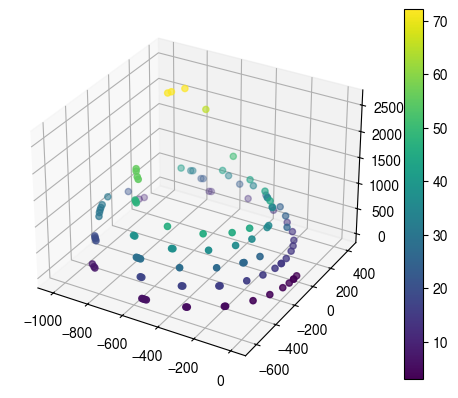

In [99]:
multi_hits = tracker_hits[tracker_hits.particle_id == 34089]
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(multi_hits.x, multi_hits.y, multi_hits.z, c=multi_hits.time, cmap="viridis")
plt.colorbar(scatter)

In [49]:
particles

event_id         particle_id           vx          vy  \
entry subentry                                                          
0     0                0    4503599627370496     0.009780   -0.003074   
      1                0    4503599627370497     0.009780   -0.003074   
      2                0    4503599627370498     0.009780   -0.003074   
      3                0    4503599627370499     0.009780   -0.003074   
      4                0    4503599627370500     0.009780   -0.003074   
...                  ...                 ...          ...         ...   
      840815           0  905404944520249676  -246.585052 -265.515167   
      840816           0  905406044031811943 -1168.682739 -454.746796   
      840817           0  905406044031877457  -474.002075  -10.628981   
      840818           0  905407143543439727     0.004192   -0.000449   
      840819           0  905407143543439728     0.004192   -0.000449   

                        vz         px         py         pz  
entry subentry                                               
0     0         -89.848335  19.532045  37.186535  72.377266  
      1         -89.848335   2.695038   4.369767   8.390165  
      2         -89.848335   1.519203   1.424487   4.669379  
      3         -89.848335   0.241998   0.348130   2.346750  
      4         -89.848335   0.930625  -0.356436   3.041831  
...                    ...        ...        ...        ...  
      840815      1.465524  -0.000014   0.000045  -0.000102  
      840816    341.894836   0.030357  -0.062274  -0.010156  
      840817    417.302246   0.035830   0.041002  -0.004408  
      840818     16.953886  -0.009112   0.054969  -7.333537  
      840819     16.953886   0.055324   0.014981  -1.315810  

[840820 rows x 8 columns]

In [39]:
particles.duplicated(subset=["particle_id"]).sum()

np.int64(0)

In [43]:
particles_df

,particle_id,pdg_id,simulator_status,charge,time,mass,vx,vy,vz,px,...,eta,phi,vr,energy,kinetic_energy,created_in_simulation,num_tracker_hits,num_calo_hits,created_inside_tracker,ended_inside_tracker
0,0,2212,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000e+00,...,44.085589,0.000000,0.000000,7000.000000,6999.061730,False,0,0,False,False
1,1,-2,0,-0.666667,-0.765510,0.000000,0.009780,-0.003074,-89.848333,-1.615587e-27,...,69.319205,3.141593,0.010252,1028.604778,1028.604778,False,0,0,False,False
2,2,2,0,0.666667,-0.765510,0.330000,0.009780,-0.003074,-89.848333,0.000000e+00,...,42.932176,0.000000,0.010252,2208.906631,2208.576631,False,0,0,False,False
3,3,2103,0,0.333333,-0.765510,0.771330,0.009780,-0.003074,-89.848333,0.000000e+00,...,42.277503,0.000000,0.010252,1147.773510,1147.002180,False,0,0,False,False
4,4,2,0,0.666667,-0.765510,0.330000,0.009780,-0.003074,-89.848333,0.000000e+00,...,43.100817,0.000000,0.010252,2614.671253,2614.341253,False,0,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
880322,880322,-11,1426063360,1.000000,9.437787,0.000511,-72.673144,1323.954928,2621.724743,-2.477711e-03,...,1.348379,2.272400,1325.947977,0.007907,0.007396,True,0,0,False,False
880323,880323,-11,1426063360,1.000000,9.349813,0.000511,-64.631563,1297.143378,2596.949831,9.149698e-03,...,0.104669,-1.258338,1298.752548,0.029932,0.029421,True,0,0,False,False
880324,880324,11,1426063360,-1.000000,8859.554688,0.000511,1249.222492,-386.984011,2908.253596,1.222434e-03,...,-0.728170,-0.835011,1307.789532,0.002381,0.001870,True,0,0,False,False
880325,880325,2112,1426063360,0.000000,25.586529,0.939565,1289.538138,400.301914,2893.576084,2.374915e-02,...,0.190010,0.980597,1350.240805,0.940569,0.001004,True,0,0,False,False


In [83]:
particles.rename(columns={"particle_id": "particle_barcode"}, inplace=True)

In [84]:
# Set px, py, ..., vz to float32
particles_df = particles_df.astype({"px": "float32", "py": "float32", "pz": "float32", "vx": "float32", "vy": "float32", "vz": "float32"})
particles = particles.astype({"px": "float32", "py": "float32", "pz": "float32", "vx": "float32", "vy": "float32", "vz": "float32"})
# Set particles

In [85]:
# match sim particles and root particles
all_particles_df = particles_df.merge(particles[["particle_barcode", "px", "py", "pz", "vx", "vy", "vz"]], on=["px", "py", "pz", "vx", "vy", "vz"], how="inner")

In [86]:
particles_df

,particle_id,pdg_id,simulator_status,charge,time,mass,vx,vy,vz,px,...,eta,phi,vr,energy,kinetic_energy,created_in_simulation,num_tracker_hits,num_calo_hits,created_inside_tracker,ended_inside_tracker
0,0,2212,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000e+00,...,44.085589,0.000000,0.000000,7000.000000,6999.061730,False,0,0,False,False
1,1,-2,0,-0.666667,-0.765510,0.000000,0.009780,-0.003074,-89.848335,-1.615587e-27,...,69.319205,3.141593,0.010252,1028.604778,1028.604778,False,0,0,False,False
2,2,2,0,0.666667,-0.765510,0.330000,0.009780,-0.003074,-89.848335,0.000000e+00,...,42.932176,0.000000,0.010252,2208.906631,2208.576631,False,0,0,False,False
3,3,2103,0,0.333333,-0.765510,0.771330,0.009780,-0.003074,-89.848335,0.000000e+00,...,42.277503,0.000000,0.010252,1147.773510,1147.002180,False,0,0,False,False
4,4,2,0,0.666667,-0.765510,0.330000,0.009780,-0.003074,-89.848335,0.000000e+00,...,43.100817,0.000000,0.010252,2614.671253,2614.341253,False,0,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
880322,880322,-11,1426063360,1.000000,9.437787,0.000511,-72.673141,1323.954956,2621.724854,-2.477711e-03,...,1.348379,2.272400,1325.947977,0.007907,0.007396,True,0,2,False,False
880323,880323,-11,1426063360,1.000000,9.349813,0.000511,-64.631561,1297.143433,2596.949951,9.149698e-03,...,0.104669,-1.258338,1298.752548,0.029932,0.029421,True,0,1,False,False
880324,880324,11,1426063360,-1.000000,8859.554688,0.000511,1249.222534,-386.984009,2908.253662,1.222434e-03,...,-0.728170,-0.835011,1307.789532,0.002381,0.001870,True,0,5,False,False
880325,880325,2112,1426063360,0.000000,25.586529,0.939565,1289.538086,400.301910,2893.576172,2.374915e-02,...,0.190010,0.980597,1350.240805,0.940569,0.001004,True,0,2,False,False


In [87]:
particles["pt"] = np.sqrt(particles["px"]**2 + particles["py"]**2)

In [88]:
particles

event_id    particle_barcode           vx          vy  \
entry subentry                                                          
0     0                0    4503599627370496     0.009780   -0.003074   
      1                0    4503599627370497     0.009780   -0.003074   
      2                0    4503599627370498     0.009780   -0.003074   
      3                0    4503599627370499     0.009780   -0.003074   
      4                0    4503599627370500     0.009780   -0.003074   
...                  ...                 ...          ...         ...   
      840815           0  905404944520249676  -246.585052 -265.515167   
      840816           0  905406044031811943 -1168.682739 -454.746796   
      840817           0  905406044031877457  -474.002075  -10.628981   
      840818           0  905407143543439727     0.004192   -0.000449   
      840819           0  905407143543439728     0.004192   -0.000449   

                        vz         px         py         pz         pt  
entry subentry                                                          
0     0         -89.848335  19.532045  37.186535  72.377266  42.004036  
      1         -89.848335   2.695038   4.369767   8.390165   5.134014  
      2         -89.848335   1.519203   1.424487   4.669379   2.082581  
      3         -89.848335   0.241998   0.348130   2.346750   0.423978  
      4         -89.848335   0.930625  -0.356436   3.041831   0.996549  
...                    ...        ...        ...        ...        ...  
      840815      1.465524  -0.000014   0.000045  -0.000102   0.000047  
      840816    341.894836   0.030357  -0.062274  -0.010156   0.069279  
      840817    417.302246   0.035830   0.041002  -0.004408   0.054452  
      840818     16.953886  -0.009112   0.054969  -7.333537   0.055719  
      840819     16.953886   0.055324   0.014981  -1.315810   0.057316  

[840820 rows x 9 columns]